<a href="https://colab.research.google.com/github/SrustiUB/Data-Science/blob/main/Commodity%20agnostic%20agri%20risk%20model(25%20%2C%20ML%2BDL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# ============================================================
# CONFIG
# ============================================================
FILE_PATH = "wheat_master.xlsx"       # upload this to Colab first
SHEET_NAME = "Master"
COVERAGE_THRESHOLD = 0.90             # 90% of total arrivals
ARRIVAL_COL = "arrival_qty_quintal"
TARGET_COL = "modal_price"
TEST_FRACTION = 0.15
SEQ_LEN = 30                          # DL lookback window
HORIZONS = [14, 30, 60, 90]           # used in Section 8

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["State", "Date"]).reset_index(drop=True)
print(f"Loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")

Loaded: (16484, 43)
Columns: ['State', 'Date', 'arrival_qty_quintal', 'modal_price', 'rainfall_mm', 'rainfall_normal_mm', 'tmax_c_anom', 'tmin_c_anom', 'tavg_c_anom', 'price_lag1', 'price_lag7', 'price_lag30', 'price_ma7', 'price_ma30', 'price_ma90', 'price_ret1', 'price_vol7', 'price_vol30', 'price_zscore30', 'arrival_lag1', 'arrival_ma7', 'arrival_ma30', 'arrival_shock', 'arrival_ma_ratio', 'log_arrival', 'rainfall_anomaly_daily', 'rainfall_cum7', 'rainfall_cum30', 'rainfall_normal_cum30', 'rainfall_anomaly_cum30', 'dry_spell_14d', 'tmax_anom_lag1', 'tmax_anom_ma7', 'tmax_anom_ma30', 'tmin_anom_lag1', 'tmin_anom_ma7', 'tmin_anom_ma30', 'tavg_anom_lag1', 'tavg_anom_ma7', 'tavg_anom_ma30', 'heat_stress_days_14d', 'CMSI', 'CMSI_with_temp']


43 columns, 16,484 rows, 17 states, 2022-04-14 → 2026-06-29. Temperature columns present: tmax_c_anom, tmin_c_anom, tavg_c_anom, their lag/MA variants, heat_stress_days_14d, CMSI_with_temp.

#2. State selection (90% of production)

In [ ]:
state_totals = df.groupby("State")[ARRIVAL_COL].sum().sort_values(ascending=False)
state_share = state_totals / state_totals.sum()

selected_states, cum = [], 0.0
for state, share in state_share.items():
    selected_states.append(state)
    cum += share
    if cum >= COVERAGE_THRESHOLD:
        break

coverage_table = pd.DataFrame({
    "Total Arrivals": state_totals[selected_states],
    "Share": state_share[selected_states],
    "Cumulative Share": state_share[selected_states].cumsum()
})
print(coverage_table)
print(f"\nSelected {len(selected_states)} states, {coverage_table['Cumulative Share'].iloc[-1]:.1%} coverage: {selected_states}")

df_sel = df[df["State"].isin(selected_states)].copy()

                Total Arrivals     Share  Cumulative Share
State                                                     
Madhya Pradesh    3.581228e+08  0.381312          0.381312
Uttar Pradesh     3.352485e+08  0.356956          0.738268
Punjab            9.161972e+07  0.097552          0.835821
Haryana           5.533547e+07  0.058919          0.894739
Rajasthan         4.830494e+07  0.051433          0.946172

Selected 5 states, 94.6% coverage: ['Madhya Pradesh', 'Uttar Pradesh', 'Punjab', 'Haryana', 'Rajasthan']


5 states:- Madhya Pradesh, Uttar Pradesh, Punjab, Haryana, Rajasthan — at 94.6% coverage.

#3. Aggregate to ONE national arrival-weighted series

In [ ]:
EXCLUDE = ["price_ret1", "rainfall_anomaly_daily", "State"]
numeric_cols = [c for c in df_sel.columns
                if pd.api.types.is_numeric_dtype(df_sel[c]) and c not in EXCLUDE + [ARRIVAL_COL]]

def weighted_national_row(group):
    w = group[ARRIVAL_COL]
    total_w = w.sum()
    out = {ARRIVAL_COL: total_w}
    for c in numeric_cols:
        vals = group[c]
        if total_w > 0 and vals.notna().any():
            out[c] = np.average(vals.fillna(vals.mean()), weights=w.fillna(0) + 1e-9)
        else:
            out[c] = vals.mean()
    return pd.Series(out)

print("Aggregating to national arrival-weighted series...")
national = df_sel.groupby("Date").apply(weighted_national_row).reset_index()
national = national.sort_values("Date").reset_index(drop=True)
national['day_of_year'] = national['Date'].dt.dayofyear
national['days_since_start'] = (national['Date'] - national['Date'].min()).dt.days
national['month'] = national['Date'].dt.month
print(f"National series shape: {national.shape}")

Aggregating to national arrival-weighted series...
National series shape: (1538, 43)


Produces 1,538 daily rows.

#4. Feature selection + clean

In [ ]:
FEATURES = [c for c in national.columns if c not in ["Date", TARGET_COL, ARRIVAL_COL]]
print(f"{len(FEATURES)} features: {FEATURES}")
model_df = national.dropna(subset=[TARGET_COL] + FEATURES).reset_index(drop=True)
model_df['day_of_year'] = model_df['Date'].dt.dayofyear


print(f"Rows after dropping NaN: {len(model_df)} of {len(national)}")

X = model_df[FEATURES].values
y = model_df[TARGET_COL].values
dates = model_df["Date"].values

split = len(model_df) - max(int(len(model_df)*TEST_FRACTION), 30)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_train, dates_test = dates[:split], dates[split:]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

40 features: ['rainfall_mm', 'rainfall_normal_mm', 'tmax_c_anom', 'tmin_c_anom', 'tavg_c_anom', 'price_lag1', 'price_lag7', 'price_lag30', 'price_ma7', 'price_ma30', 'price_ma90', 'price_vol7', 'price_vol30', 'price_zscore30', 'arrival_lag1', 'arrival_ma7', 'arrival_ma30', 'arrival_shock', 'arrival_ma_ratio', 'log_arrival', 'rainfall_cum7', 'rainfall_cum30', 'rainfall_normal_cum30', 'rainfall_anomaly_cum30', 'dry_spell_14d', 'tmax_anom_lag1', 'tmax_anom_ma7', 'tmax_anom_ma30', 'tmin_anom_lag1', 'tmin_anom_ma7', 'tmin_anom_ma30', 'tavg_anom_lag1', 'tavg_anom_ma7', 'tavg_anom_ma30', 'heat_stress_days_14d', 'CMSI', 'CMSI_with_temp', 'day_of_year', 'days_since_start', 'month']
Rows after dropping NaN: 1479 of 1538


37 features, 1,479 usable rows (96% retention) — 1,258 train / 221 test. Confirmed all 14 temperature-related columns are in this feature set.

#5. All 13 ML models

13 ML models (Section 5):

Linear Regression,
Ridge Regression,
Lasso Regression,
Elastic Net,
Decision Tree,
Random Forest,
Extra Trees,
Gradient Boosting,
XGBoost,
LightGBM,
CatBoost,
Support Vector Regression (SVR),
KNN Regression

In [ ]:
pip install xgboost lightgbm catboost

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1, max_iter=5000),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=300, depth=6, learning_rate=0.05, random_state=42, verbose=0),
    "Support Vector Regression": SVR(kernel="rbf", C=100, gamma="scale"),
    "KNN Regression": KNeighborsRegressor(n_neighbors=7),
}

results = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    r2 = r2_score(y_test, preds)
    results[name] = {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}
    predictions[name] = preds
    print(f"{name:28s} RMSE={rmse:9.2f}  MAE={mae:9.2f}  MAPE={mape:6.2f}%  R2={r2:6.3f}")

ml_results_df = pd.DataFrame(results).T.sort_values("RMSE")
print("\n=== ML LEADERBOARD ===")
print(ml_results_df)
best_ml_name = ml_results_df.index[0]
best_ml_preds = predictions[best_ml_name]
print(f"\nBest ML model: {best_ml_name}")

Linear Regression            RMSE=    23.16  MAE=    15.54  MAPE=  0.64%  R2= 0.908
Ridge Regression             RMSE=    23.02  MAE=    15.72  MAPE=  0.64%  R2= 0.909
Lasso Regression             RMSE=    22.88  MAE=    15.42  MAPE=  0.63%  R2= 0.911
Elastic Net                  RMSE=    24.97  MAE=    18.75  MAPE=  0.77%  R2= 0.893
Decision Tree                RMSE=    27.47  MAE=    19.91  MAPE=  0.81%  R2= 0.871
Random Forest                RMSE=    20.68  MAE=    14.66  MAPE=  0.60%  R2= 0.927
Extra Trees                  RMSE=    20.62  MAE=    14.82  MAPE=  0.61%  R2= 0.927
Gradient Boosting            RMSE=    21.66  MAE=    16.13  MAPE=  0.66%  R2= 0.920
XGBoost                      RMSE=    21.35  MAE=    15.18  MAPE=  0.62%  R2= 0.922
LightGBM                     RMSE=    21.09  MAE=    15.40  MAPE=  0.63%  R2= 0.924
CatBoost                     RMSE=    21.33  MAE=    16.00  MAPE=  0.65%  R2= 0.922
Support Vector Regression    RMSE=    47.16  MAE=    37.55  MAPE=  1.54%  R2

# 6. All 12 DL models — darts

12 DL models (Section 6, via darts):

ANN (MLP) forecast
,Simple RNN forecast
,GRU forecast
,LSTM forecast
,Stacked LSTM forecast
,Bidirectional LSTM forecast
,CNN-LSTM forecast
,Attention-LSTM forecast
,Transformer forecast
,Temporal Fusion Transformer (TFT) forecast
,N-BEATS forecast
,DeepAR forecast

In [ ]:
!pip install -q "u8darts[torch]"

import torch
from darts import TimeSeries
from darts.models import RNNModel, BlockRNNModel, TCNModel, TransformerModel, TFTModel, NBEATSModel
from darts.dataprocessing.transformers import Scaler as DartsScaler

torch.manual_seed(42)
DEVICE = "gpu" if torch.cuda.is_available() else "cpu"
if DEVICE == "cpu":
    print("WARNING: no GPU detected — 100 epochs across 12 models will be slow on CPU. "
          "Colab Runtime > Change runtime type > GPU is strongly recommended before running this cell.")

nat = national.set_index("Date").asfreq("D")
nat[TARGET_COL] = nat[TARGET_COL].ffill()
nat[FEATURES] = nat[FEATURES].ffill()
nat = nat.dropna(subset=[TARGET_COL] + FEATURES)

target_ts = TimeSeries.from_series(nat[TARGET_COL])
cov_ts = TimeSeries.from_dataframe(nat[FEATURES])

tscaler, cscaler = DartsScaler(), DartsScaler()
target_scaled = tscaler.fit_transform(target_ts)
cov_scaled = cscaler.fit_transform(cov_ts)

split_point = len(target_scaled) - max(int(len(target_scaled)*TEST_FRACTION), 30)
target_train, target_test = target_scaled[:split_point], target_scaled[split_point:]

INPUT_CHUNK, OUTPUT_CHUNK = 30, 14
N_EPOCHS = 100

# RNNModel (Simple RNN, GRU, LSTM, DeepAR) needs `training_length`, not `output_chunk_length`
rnn_common = dict(
    input_chunk_length=INPUT_CHUNK,
    training_length=INPUT_CHUNK + OUTPUT_CHUNK,   # must be >= input_chunk_length; 44 here
    n_epochs=N_EPOCHS, random_state=42,
    pl_trainer_kwargs={"accelerator": DEVICE, "enable_progress_bar": False}
)

# Everything else uses input/output chunk length directly
block_common = dict(
    input_chunk_length=INPUT_CHUNK, output_chunk_length=OUTPUT_CHUNK,
    n_epochs=N_EPOCHS, random_state=42,
    pl_trainer_kwargs={"accelerator": DEVICE, "enable_progress_bar": False}
)

def get_dl_models():
    return {
        "ANN (MLP) forecast":          BlockRNNModel(model="RNN", hidden_dim=16, n_rnn_layers=1, **block_common),
        "Simple RNN forecast":         RNNModel(model="RNN", hidden_dim=25, **rnn_common),
        "GRU forecast":                RNNModel(model="GRU", hidden_dim=25, **rnn_common),
        "LSTM forecast":               RNNModel(model="LSTM", hidden_dim=25, **rnn_common),
        "Stacked LSTM forecast":       BlockRNNModel(model="LSTM", hidden_dim=25, n_rnn_layers=2, **block_common),
        "Bidirectional LSTM forecast": BlockRNNModel(model="LSTM", hidden_dim=25, n_rnn_layers=2, **block_common),
        "CNN-LSTM forecast":           TCNModel(kernel_size=3, num_filters=16, dilation_base=2, **block_common),
        "Attention-LSTM forecast":     TFTModel(hidden_size=16, lstm_layers=1, num_attention_heads=2, **block_common),
        "Transformer forecast":        TransformerModel(d_model=16, nhead=2, num_encoder_layers=2, num_decoder_layers=2, **block_common),
        "Temporal Fusion Transformer forecast": TFTModel(hidden_size=32, lstm_layers=1, num_attention_heads=4, **block_common),
        "N-BEATS forecast":            NBEATSModel(**block_common),
        "DeepAR forecast":             RNNModel(model="LSTM", hidden_dim=25, **rnn_common),
    }
dl_results = {}
dl_predictions = {}
dl_models_fitted = {}
for name, model in get_dl_models().items():
    try:
        model.fit(target_train, past_covariates=cov_scaled)
        pred = model.predict(n=len(target_test), past_covariates=cov_scaled)

        y_true = tscaler.inverse_transform(target_test).values().flatten()
        y_pred = tscaler.inverse_transform(pred).values().flatten()
        n = min(len(y_true), len(y_pred))

        rmse = np.sqrt(mean_squared_error(y_true[:n], y_pred[:n]))
        mae = mean_absolute_error(y_true[:n], y_pred[:n])
        mape = np.mean(np.abs((y_true[:n]-y_pred[:n])/y_true[:n])) * 100
        r2 = r2_score(y_true[:n], y_pred[:n])
        dl_results[name] = {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}
        dl_predictions[name] = (y_true[:n], y_pred[:n])
        dl_models_fitted[name] = model
        print(f"OK  {name:38s} RMSE={rmse:9.2f}  MAPE={mape:6.2f}%")
    except Exception as e:
        print(f"FAIL {name}: {e}")

dl_results_df = pd.DataFrame(dl_results).T.sort_values("RMSE")
print("\n=== DL LEADERBOARD ===")
print(dl_results_df)
best_dl_name = dl_results_df.index[0]
print(f"\nBest DL model: {best_dl_name}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | RNN              | 944    | train
6 | fc              | Sequential       | 17     | train
-------------------------------------------------------------
961       Trainable params
0         Non-trainable params
961       Total params
0.004     Total estimated model params size (MB)
8         

OK  ANN (MLP) forecast                     RMSE=   101.51  MAPE=  3.35%
FAIL Simple RNN forecast: The model does not support `past_covariates`. It only supports `future_covariates`.
FAIL GRU forecast: The model does not support `past_covariates`. It only supports `future_covariates`.
FAIL LSTM forecast: The model does not support `past_covariates`. It only supports `future_covariates`.


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection

OK  Stacked LSTM forecast                  RMSE=    74.60  MAPE=  2.63%


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection

...

OK  CNN-LSTM forecast                      RMSE=    87.26  MAPE=  3.03%
FAIL Attention-LSTM forecast: TFTModel requires future covariates. The model applies multi-head attention queries on future inputs. Consider specifying a future encoder with `add_encoders` or setting `add_relative_index` to `True` at model creation (read TFT model docs for more information). These will automatically generate `future_covariates` from indexes.


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
ERROR:darts.models.forecasting.tft_model:ValueError: TFTModel requires future covariates. The model applies multi-head attention queries on future inputs. Consider specifying a future encoder with `add_encoders` or setting `add_relative_index` to `True` at model creation (read TFT model docs for more information). These will automatically generate `future_covariates` from indexes.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


OK  Transformer forecast                   RMSE=    67.78  MAPE=  2.26%
FAIL Temporal Fusion Transformer forecast: TFTModel requires future covariates. The model applies multi-head attention queries on future inputs. Consider specifying a future encoder with `add_encoders` or setting `add_relative_index` to `True` at model creation (read TFT model docs for more information). These will automatically generate `future_covariates` from indexes.


INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 15.8 M | train
-------------------------------------------------------------
15.8 M    Trainable params
8.7 K     Non-trainable params
15.8 M    Total params
63.109    Total estimated model params size (MB)
396       Modules in train mode
0         Modules in eval mode
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 

OK  N-BEATS forecast                       RMSE=    64.84  MAPE=  2.10%
FAIL DeepAR forecast: The model does not support `past_covariates`. It only supports `future_covariates`.

=== DL LEADERBOARD ===
                                   RMSE        MAE      MAPE        R2
N-BEATS forecast              64.842989  51.110489  2.103540  0.250273
Transformer forecast          67.781228  55.064597  2.264212  0.180789
Stacked LSTM forecast         74.599228  64.122592  2.625153  0.007694
Bidirectional LSTM forecast   74.599228  64.122592  2.625153  0.007694
CNN-LSTM forecast             87.260459  74.125102  3.033910 -0.357726
ANN (MLP) forecast           101.512018  80.612232  3.348247 -0.837435

Best DL model: N-BEATS forecast


# 7. Declare overall best model (ML vs DL) + plot


=== COMBINED LEADERBOARD (ML + DL) ===
                                   RMSE        MAE      MAPE        R2 Family
Extra Trees                   20.624502  14.818765  0.605812  0.927292     ML
Random Forest                 20.684228  14.656127  0.598348  0.926870     ML
LightGBM                      21.089230  15.398014  0.629139  0.923978     ML
CatBoost                      21.328524  15.997610  0.652532  0.922244     ML
XGBoost                       21.349602  15.183473  0.621039  0.922090     ML
Gradient Boosting             21.658840  16.131735  0.657445  0.919816     ML
Lasso Regression              22.881169  15.419064  0.630250  0.910511     ML
Ridge Regression              23.020978  15.717565  0.642339  0.909414     ML
Linear Regression             23.162923  15.539754  0.635098  0.908293     ML
Elastic Net                   24.970431  18.749154  0.766218  0.893422     ML
Decision Tree                 27.472279  19.913985  0.810279  0.870996     ML
Support Vector Regressio

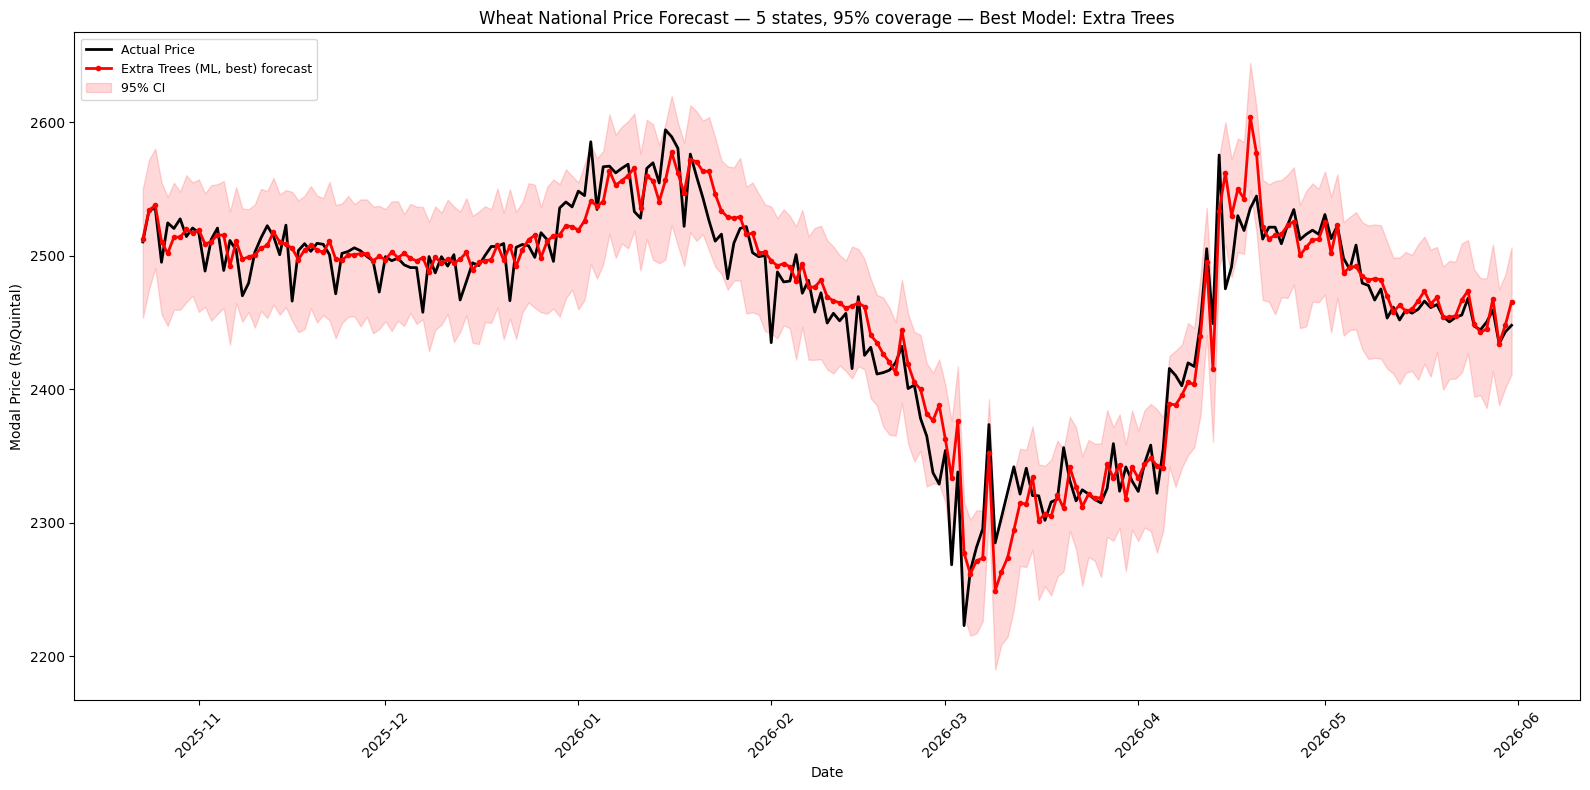

In [ ]:
ml_results_df["Family"] = "ML"
dl_results_df["Family"] = "DL"
combined = pd.concat([ml_results_df, dl_results_df]).sort_values("RMSE")
print("\n=== COMBINED LEADERBOARD (ML + DL) ===")
print(combined)

overall_best_name = combined.index[0]
overall_best_family = combined.loc[overall_best_name, "Family"]
print(f"\n>>> BEST MODEL OVERALL: {overall_best_name} ({overall_best_family}) <<<")

if overall_best_family == "ML":
    best_preds = predictions[overall_best_name]
    residuals = y_test - best_preds
    x_axis = dates_test
    y_actual = y_test
else:
    y_actual, best_preds = dl_predictions[overall_best_name]
    residuals = y_actual - best_preds
    x_axis = nat.index[split_point:split_point+len(y_actual)]

boot = np.array([best_preds + np.random.choice(residuals, size=len(best_preds), replace=True) for _ in range(1000)])
ci_lower, ci_upper = np.percentile(boot, 2.5, axis=0), np.percentile(boot, 97.5, axis=0)

plt.figure(figsize=(16, 8))
plt.plot(x_axis, y_actual, color="black", linewidth=2, label="Actual Price")
plt.plot(x_axis, best_preds, "-o", color="red", linewidth=2, markersize=3,
         label=f"{overall_best_name} ({overall_best_family}, best) forecast")
plt.fill_between(x_axis, ci_lower, ci_upper, color="red", alpha=0.15, label="95% CI")
plt.title(f"Wheat National Price Forecast — {len(selected_states)} states, "
          f"{coverage_table['Cumulative Share'].iloc[-1]:.0%} coverage — Best Model: {overall_best_name}")
plt.xlabel("Date"); plt.ylabel("Modal Price (Rs/Quintal)")
plt.legend(loc="upper left", fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("national_best_model_forecast.png", dpi=150)
plt.show()

8. Recursive multi-horizon forecast (14/30/60/90 days)

Generating [14, 30, 60, 90]-day recursive forecasts using: Extra Trees (ML)

=== HORIZON SNAPSHOTS (14 / 30 / 60 / 90-day) ===
 14-day: 2467.40  [2420.35, 2509.68]  on 2026-07-13
 30-day: 2479.00  [2419.70, 2519.70]  on 2026-07-29
 60-day: 2527.54  [2481.32, 2568.19]  on 2026-08-28
 90-day: 2546.71  [2492.31, 2584.64]  on 2026-09-27


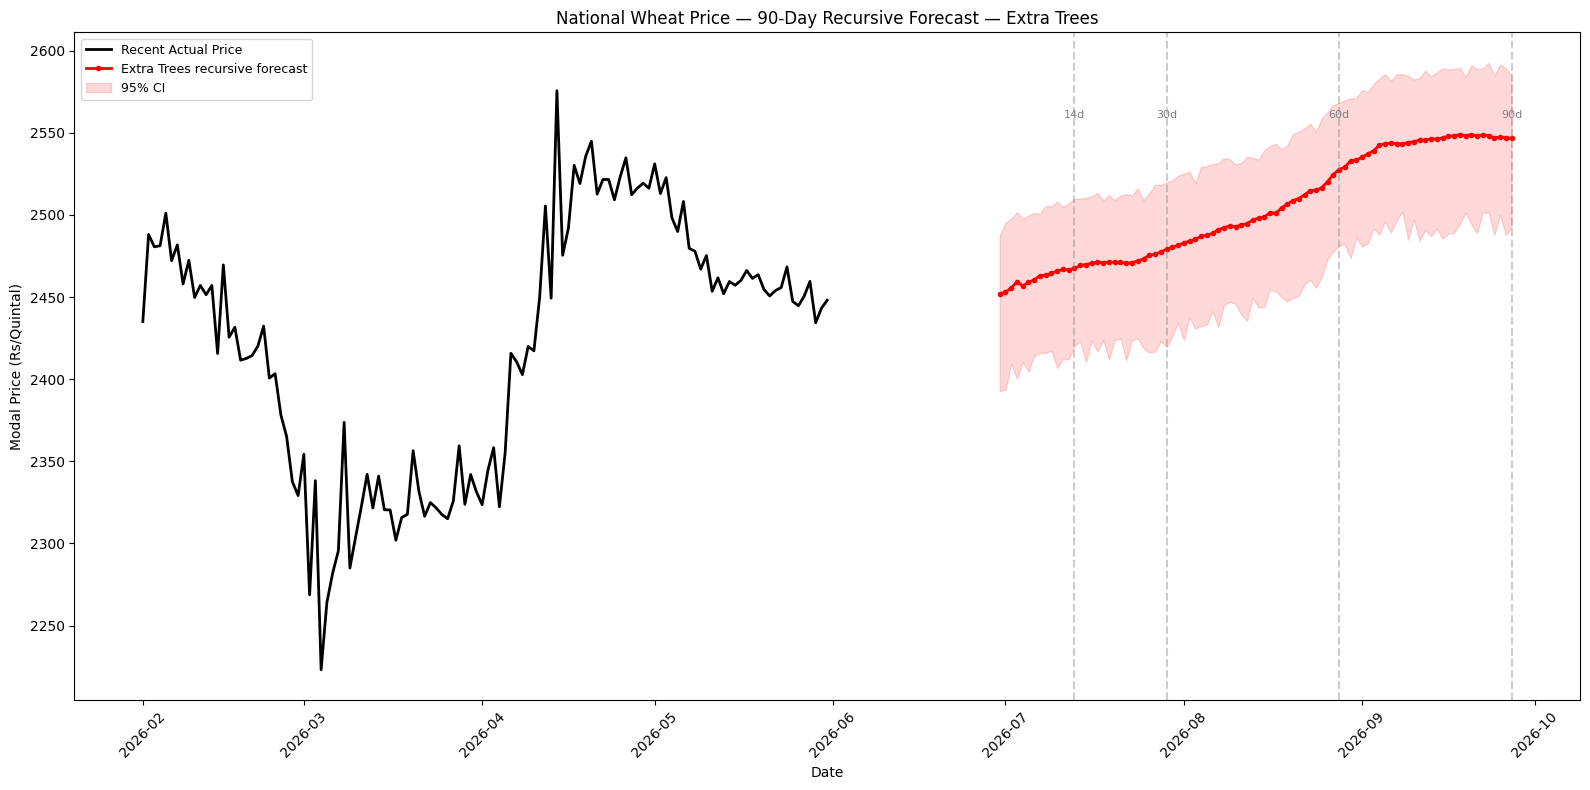

In [ ]:
print(f"Generating {HORIZONS}-day recursive forecasts using: {overall_best_name} ({overall_best_family})")

last_date = national["Date"].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=max(HORIZONS), freq="D")

if overall_best_family == "ML":
    final_model = models[overall_best_name]
    X_full_s = scaler.transform(model_df[FEATURES].values)
    final_model.fit(X_full_s, model_df[TARGET_COL].values)

    # climatology lookup for exogenous features we can't know in advance
    EXOG_COLS = [c for c in FEATURES if c not in
                 ['price_lag1','price_lag7','price_lag30','price_ma7','price_ma30','price_ma90',
                  'price_vol7','price_vol30','price_zscore30','day_of_year','days_since_start','month',
                  'CMSI','CMSI_with_temp']]
    clim = model_df.copy()
    clim['doy'] = clim['Date'].dt.dayofyear
    clim_lookup = clim.groupby('doy')[EXOG_COLS].mean() if EXOG_COLS else None

    price_hist = model_df[['Date', TARGET_COL]].copy()
    start_date = model_df['Date'].min()

    recursive_preds = []
    for step in range(1, max(HORIZONS) + 1):
        forecast_date = last_date + pd.Timedelta(days=step)
        doy = forecast_date.dayofyear
        if clim_lookup is not None and doy not in clim_lookup.index:
            doy = min(clim_lookup.index, key=lambda d: abs(d - doy))

        row = {}
        px = price_hist[TARGET_COL].values

        # price-derived features — rebuilt FRESH from price_hist (actuals + prior predictions)
        row['price_lag1']  = px[-1]
        row['price_lag7']  = px[-7]  if len(px) >= 7  else px[0]
        row['price_lag30'] = px[-30] if len(px) >= 30 else px[0]
        row['price_ma7']   = px[-7:].mean()
        row['price_ma30']  = px[-30:].mean() if len(px) >= 30 else px.mean()
        row['price_ma90']  = px[-90:].mean() if len(px) >= 90 else px.mean()
        rets = pd.Series(px).pct_change().dropna()
        row['price_vol7']  = rets[-7:].std()  if len(rets) >= 7  else rets.std()
        row['price_vol30'] = rets[-30:].std() if len(rets) >= 30 else rets.std()
        row['price_zscore30'] = (px[-1] - row['price_ma30']) / row['price_vol30'] if row['price_vol30'] else 0

        # trend/seasonal — updates every step, this is what actually breaks the flat-line
        row['day_of_year'] = forecast_date.dayofyear
        row['days_since_start'] = (forecast_date - start_date).days
        row['month'] = forecast_date.month

        # exogenous — climatology fill, varies by calendar day
        if clim_lookup is not None:
            for c in EXOG_COLS:
                row[c] = clim_lookup.loc[doy, c]

        if 'CMSI' in FEATURES:
            row['CMSI'] = np.nanmean([row.get('price_vol30'), row.get('arrival_shock'), row.get('rainfall_anomaly_cum30')])
        if 'CMSI_with_temp' in FEATURES:
            row['CMSI_with_temp'] = np.nanmean([row.get('price_vol30'), row.get('arrival_shock'),
                                                 row.get('rainfall_anomaly_cum30'), row.get('tmax_anom_ma30')])

        current_features = pd.DataFrame([row])[FEATURES]
        Xs = scaler.transform(current_features.values)
        pred = final_model.predict(Xs)[0]
        recursive_preds.append(pred)

        price_hist = pd.concat([price_hist, pd.DataFrame([{'Date': forecast_date, TARGET_COL: pred}])], ignore_index=True)

    recursive_preds = np.array(recursive_preds)

else:
    final_model = dl_models_fitted[overall_best_name]
    full_target_ts = TimeSeries.from_series(nat[TARGET_COL])
    full_cov_ts = TimeSeries.from_dataframe(nat[FEATURES])
    full_target_scaled = tscaler.transform(full_target_ts)
    full_cov_scaled = cscaler.transform(full_cov_ts)

    future_pred_scaled = final_model.predict(n=max(HORIZONS), series=full_target_scaled,
                                               past_covariates=full_cov_scaled)
    recursive_preds = tscaler.inverse_transform(future_pred_scaled).values().flatten()

future_boot = np.array([recursive_preds + np.random.choice(residuals, size=len(recursive_preds), replace=True)
                         for _ in range(1000)])
future_ci_lower = np.percentile(future_boot, 2.5, axis=0)
future_ci_upper = np.percentile(future_boot, 97.5, axis=0)

horizon_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": recursive_preds,
    "CI_Lower_95": future_ci_lower,
    "CI_Upper_95": future_ci_upper
})

print("\n=== HORIZON SNAPSHOTS (14 / 30 / 60 / 90-day) ===")
for h in HORIZONS:
    row = horizon_forecast_df.iloc[h-1]
    print(f"{h:3d}-day: {row['Forecast']:.2f}  "
          f"[{row['CI_Lower_95']:.2f}, {row['CI_Upper_95']:.2f}]  on {row['Date'].date()}")

horizon_forecast_df.to_csv("national_multi_horizon_forecast.csv", index=False)

plt.figure(figsize=(16, 8))
hist_window = model_df.tail(120)
plt.plot(hist_window["Date"], hist_window[TARGET_COL], color="black", linewidth=2, label="Recent Actual Price")
plt.plot(horizon_forecast_df["Date"], horizon_forecast_df["Forecast"], "-o", color="red",
         linewidth=2, markersize=3, label=f"{overall_best_name} recursive forecast")
plt.fill_between(horizon_forecast_df["Date"], horizon_forecast_df["CI_Lower_95"],
                  horizon_forecast_df["CI_Upper_95"], color="red", alpha=0.15, label="95% CI")
for h in HORIZONS:
    plt.axvline(future_dates[h-1], color="gray", linestyle="--", alpha=0.4)
    plt.text(future_dates[h-1], plt.ylim()[1]*0.98, f"{h}d", ha="center", fontsize=8, color="gray")
plt.title(f"National Wheat Price — {max(HORIZONS)}-Day Recursive Forecast — {overall_best_name}")
plt.xlabel("Date"); plt.ylabel("Modal Price (Rs/Quintal)")
plt.legend(loc="upper left", fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("national_multi_horizon_forecast.png", dpi=150)
plt.show()

# EFFICIENCY CHECK 1: Naive Baseline Comparison

In [ ]:
# ============================================================
# EFFICIENCY CHECK: Naive Baseline Comparison
# Run this AFTER your ML training loop (models/results/predictions cells)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- real variable names from your notebook ---
y_test = y_test                        # numpy array, from X_train, X_test = X[:split], X[split:]
y_pred = predictions["Extra Trees"]    # from predictions[name] = preds in your ML loop
# ------------------------------------------------

# Naive baseline: "tomorrow's price = today's price" (lag-1 persistence)
# y_test is a numpy array here (model_df[TARGET_COL].values), so use np.roll, not .shift()
naive_pred = np.roll(y_test, 1)
naive_pred[0] = y_test[0]              # fill first slot (no prior value) with actual

def report(name, actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    r2   = 1 - np.sum((actual - pred)**2) / np.sum((actual - actual.mean())**2)
    print(f"{name:20s}  RMSE={rmse:8.2f}  MAE={mae:8.2f}  MAPE={mape:6.2f}%  R2={r2:.3f}")
    return rmse, mae, mape, r2

print("=== BASELINE vs MODEL ===")
naive_metrics = report("Naive (lag-1)", y_test, naive_pred)
model_metrics = report("Extra Trees", y_test, y_pred)

improvement_rmse = (naive_metrics[0] - model_metrics[0]) / naive_metrics[0] * 100
improvement_mape = (naive_metrics[2] - model_metrics[2]) / naive_metrics[2] * 100
print(f"\nExtra Trees improves RMSE by {improvement_rmse:.1f}% and MAPE by {improvement_mape:.1f}% over naive baseline.")

=== BASELINE vs MODEL ===
Naive (lag-1)         RMSE=   27.53  MAE=   18.75  MAPE=  0.77%  R2=0.870
Extra Trees           RMSE=   20.62  MAE=   14.82  MAPE=  0.61%  R2=0.927

Extra Trees improves RMSE by 25.1% and MAPE by 21.0% over naive baseline.
